In [1]:
import numpy as np
import pandas as pd
import nitools as nit
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.evaluation as ev
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import Functional_Fusion.dataset as fdata
import Functional_Fusion.atlas_map as am
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.evaluation as ev
import SUITPy as suit

In [2]:
# the label
label_img = nib.load(gl.atlas_dir + "/tpl-MNI152NLin6Asym/atl-Platchi5_space-MNI152NLin6Asym_dseg.nii")
label_data = label_img.get_fdata().squeeze()

# atlas
cereb_atlas, cereb_ainf = am.get_atlas('MNISymC3')
hipp_atlas, hipp_ainf = am.get_atlas('Platchi5')

In [3]:
new_data = np.zeros(label_data.shape, dtype=np.uint8)

for label in range(1, 6):

    vox = np.argwhere(label_data == label)
    xyz = apply_affine(label_img.affine, vox)

    left = xyz[:, 0] < 0
    right = xyz[:, 0] > 0

    # 1L, 1R, 2L, 2R, ...
    left_label = 2 * label - 1
    right_label = 2 * label

    new_data[tuple(vox[left].T)] = left_label
    new_data[tuple(vox[right].T)] = right_label

new_label_img = nib.Nifti1Image(
    new_data,
    label_img.affine,
    label_img.header
)

new_label_data = new_label_img.get_fdata().squeeze()

label_vec, labels = hipp_atlas.get_parcel(new_label_img)
names = ['1L', '1R', '2L', '2R', '3L', '3R', '4L', '4R', '5L', '5R']
print(labels)
print(names)

[ 1  2  3  4  5  6  7  8  9 10]
['1L', '1R', '2L', '2R', '3L', '3R', '4L', '4R', '5L', '5R']


In [6]:
config = rm.get_train_config(log_alpha=0,
                                 crossed='half',
                                 type='CondHalf',
                                 cond_num='all',
                                 subj_list='all',
                                 cerebellum='MNISymC3',
                                 parcellation='Icosahedron1002',
                                 train_dataset='MDTB',
                                 method='NNLS',
                                 train_ses='all',
                                 add_rest=False,
                                 std_cortex='parcel',
                                 std_cerebellum='global',
                                 cortical_cerebellar_act='ind',
                                 append=False)

In [7]:
subj = rm.get_subj_list('all', 'MDTB')

# Load the data
HH, info, _ = fdata.get_dataset(gl.base_dir,
                                   'MDTB',
                                   sess='all',
                                   subj=subj,
                                   atlas='MNIAsymHippocampus',
                                   type=config["type"])

HH, info_h = rm.prepare_data(HH, info, config)
for i in range(HH.shape[0]):
    if 'std_cortex' in config.keys():
        HH[i,:,:] = rm.std_data(HH[i,:,:], config['std_cortex'])
H = HH.mean(axis=0)

# Load the data
XX, info_x = rm.get_cortical_data('MDTB', 'all', subj, config)
X = XX.mean(axis=0)

# Load the data
YY, info_y = rm.get_cerebellar_data('MDTB', 'all', subj, config)
Y = YY.mean(axis=0)

/home/UWO/ashahb7/Github/cortico_cereb_connectivity/cortico_cereb_connectivity/run_model.py:395: RuntimeWarning: invalid value encountered in divide
  return  np.nan_to_num(Y/sc)
/home/UWO/ashahb7/Github/Functional_Fusion/Functional_Fusion/dataset.py:254: RuntimeWarning: Mean of empty slice
  parcel_data[..., i] = fcn(


In [8]:
R, _, _, _ = ev.calculate_reliability(H, info_h)
print(f'Hippocamp reliability: {R:.2f}')
R, _, _, _ = ev.calculate_reliability(X, info_x)
print(f'Cortical reliability: {R:.2f}')
R, _, _, _ = ev.calculate_reliability(Y, info_y)
print(f'Cerebellum reliability: {R:.2f}')

Hippocamp reliability: 0.76
Cortical reliability: 0.93
Cerebellum reliability: 0.86


In [9]:
def calc_corr(H, Y):
    # should already be zero mean
    A = H - H.mean(axis=0, keepdims=True)
    B = Y - Y.mean(axis=0, keepdims=True)

    A /= np.linalg.norm(A, axis=0, keepdims=True) # should already be norm 1
    B /= np.linalg.norm(B, axis=0, keepdims=True)

    return A.T @ B

In [10]:
# aggregate data within each label
Hl = np.zeros((H.shape[0], len(labels)))
for i, label in enumerate(labels):
    Hl[:, i] = H[:, label_vec == label].mean(axis=1)

In [24]:
corr_hh = calc_corr(H, H)
corr_hlhl = calc_corr(Hl, Hl)
corr_hy = calc_corr(Hl, Y)
corr_hx = calc_corr(Hl, X)

/localscratch/tmp/ipykernel_1633385/2844972330.py:7: RuntimeWarning: invalid value encountered in divide
  B /= np.linalg.norm(B, axis=0, keepdims=True)


In [25]:
print(corr_hh)

[[1.         0.92550583 0.72344642 ... 0.36317736 0.39968957 0.40945804]
 [0.92550583 1.         0.84780021 ... 0.36059873 0.4104904  0.40660111]
 [0.72344642 0.84780021 1.         ... 0.38367433 0.29635614 0.34705823]
 ...
 [0.36317736 0.36059873 0.38367433 ... 1.         0.45206672 0.68914767]
 [0.39968957 0.4104904  0.29635614 ... 0.45206672 1.         0.83178779]
 [0.40945804 0.40660111 0.34705823 ... 0.68914767 0.83178779 1.        ]]


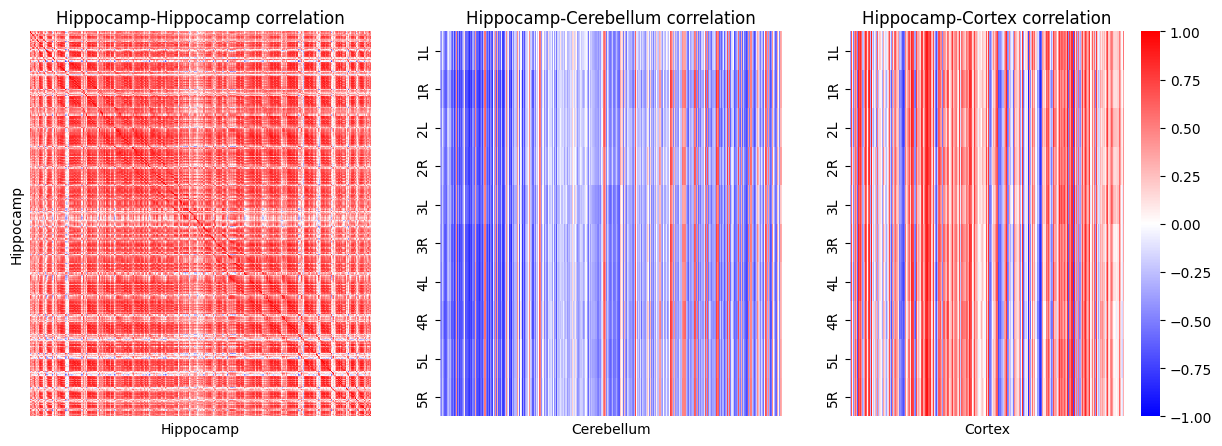

In [30]:
plt.subplots(1,3,figsize=(15, 5))#, sharey=True)

plt.subplot(1,3,1)
sns.heatmap(corr_hh, cmap='bwr', center=0, xticklabels=False, yticklabels=False, vmin=-1, vmax=1, cbar=False)
plt.title('Hippocamp-Hippocamp correlation')
plt.xlabel('Hippocamp')
plt.ylabel('Hippocamp')

plt.subplot(1,3,2)
sns.heatmap(corr_hy, cmap='bwr', center=0, xticklabels=False, yticklabels=names, vmin=-1, vmax=1, cbar=False)
plt.title('Hippocamp-Cerebellum correlation')
plt.xlabel('Cerebellum')

plt.subplot(1,3,3)
sns.heatmap(corr_hx, cmap='bwr', center=0, xticklabels=False, yticklabels=names, vmin=-1, vmax=1)
plt.title('Hippocamp-Cortex correlation')
plt.xlabel('Cortex');

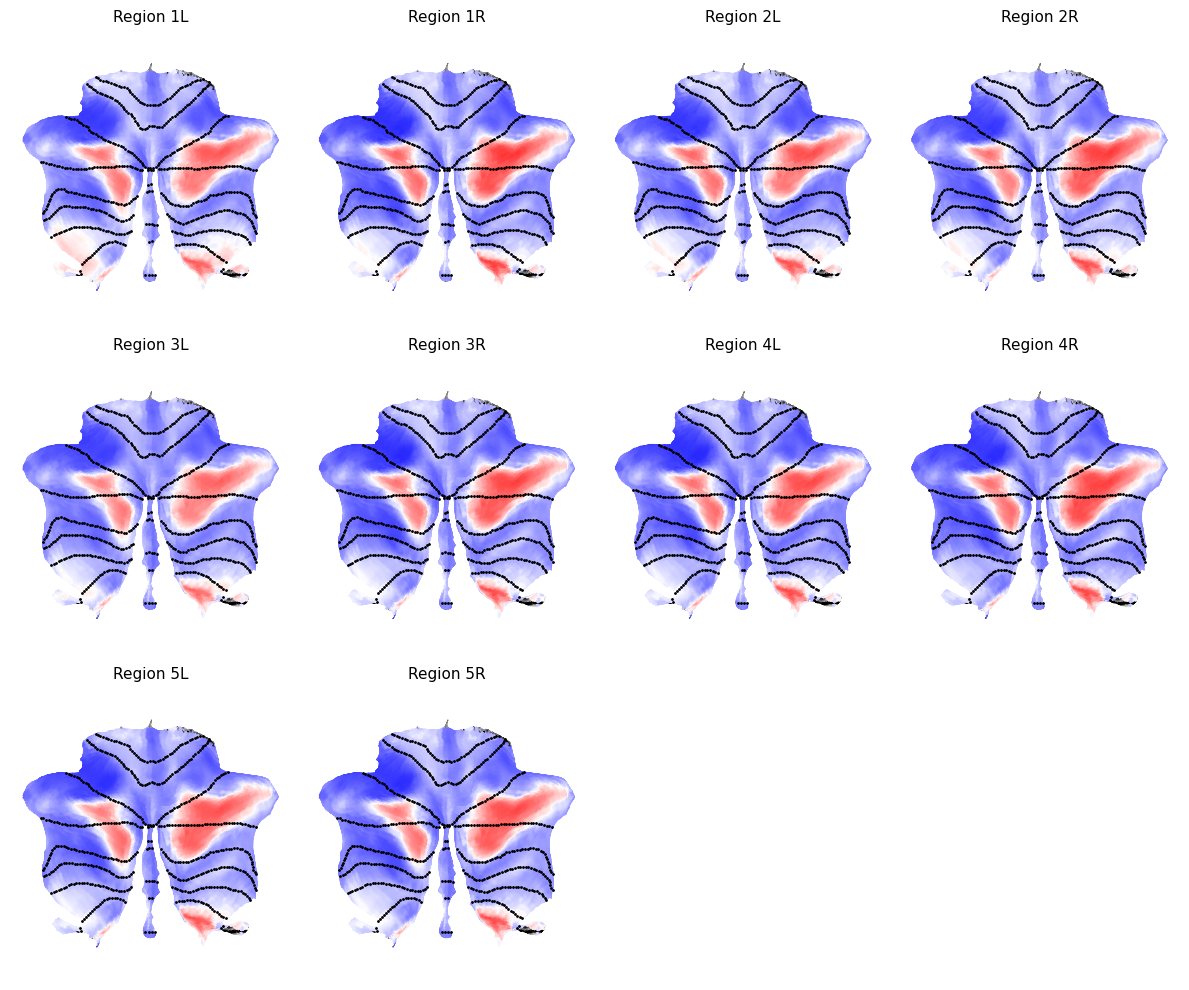

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
for i, (label, name) in enumerate(zip(labels, names)):
    corr_vec = corr_hy[i, :]
    nifti_image = cereb_atlas.data_to_nifti(corr_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(3, 4, i+1)
    suit.flatmap.plot(data, cmap='bwr', new_figure=False, cscale=[-1, 1])
    plt.title(f'Region {name}', fontsize=11)

plt.subplot(3, 4, 11).axis('off')
plt.subplot(3, 4, 12).axis('off')
plt.tight_layout();

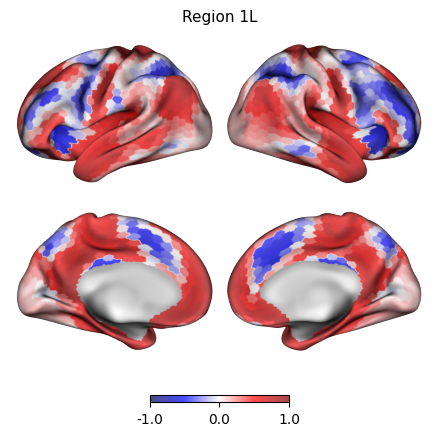

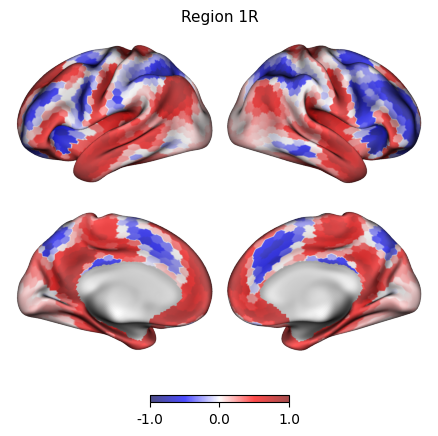

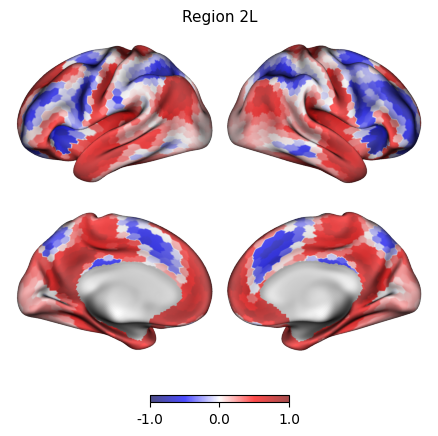

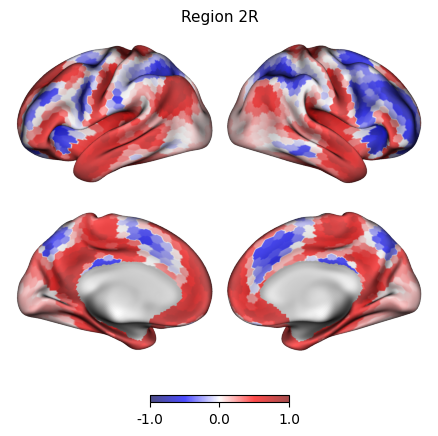

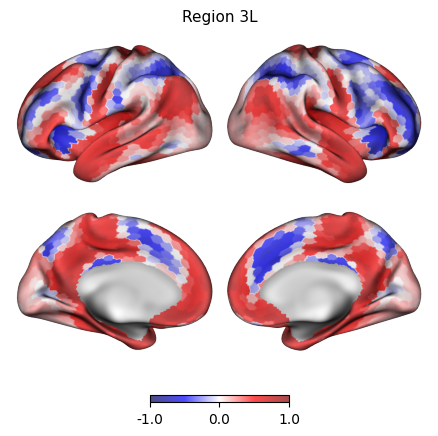

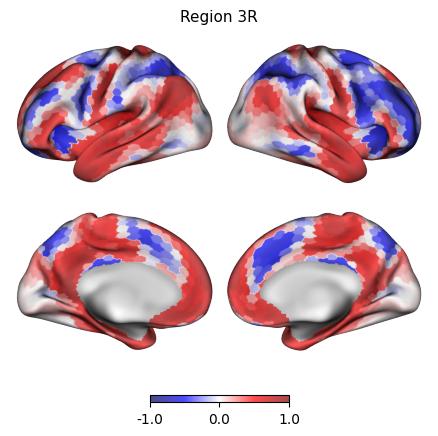

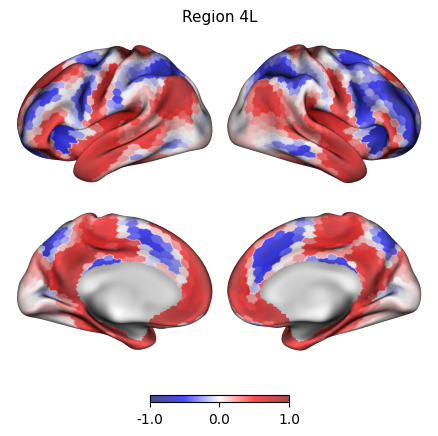

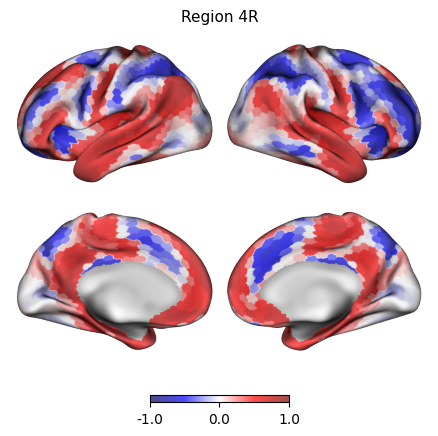

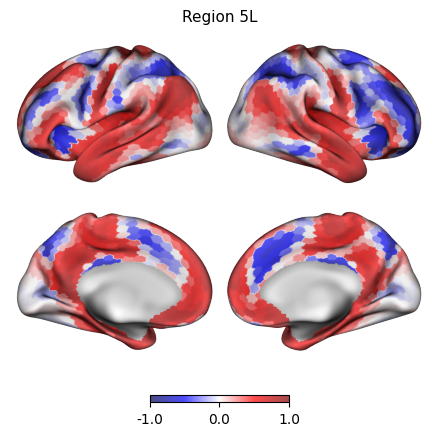

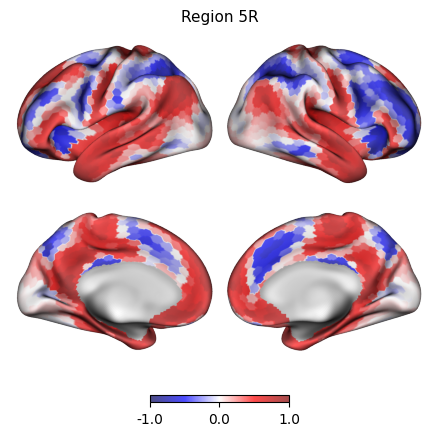

<Figure size 640x480 with 0 Axes>

In [ ]:
label_fs = [gl.atlas_dir + f"/tpl-fs32k/Icosahedron1002.{hemi}.label.gii" for hemi in ["L", "R"]]

for i, (label, name) in enumerate(zip(labels, names)):
    corr_vec = corr_hx[i, :]
    corr_vec = corr_vec[None, :]
    cifti_corr = cio.model_to_cifti(corr_vec, src_roi=label_fs)
    plu.plot_cortex_map(cifti_corr, cmap='seismic', cscale=[-1, 1], alpha=0.7, zero_transparent=False)
    plt.title(f'Region {name}', fontsize=11)
    plt.show()